---
- title: "Chapter 4--5: Learning Sheet"
- author: "Sheng-Mao"
- date: "4/16/2025"
- output: html_document
---

In [ ]:
install.packages("pROC")

# 範例：Horseshore Crab Problem

## 實驗 

鱟為鱟科動物的通稱，又名「馬蹄蟹」、「蟹兜」、「夫妻魚」，屬於劍尾目的海生節肢動物，而劍尾目最早出現的時間可回溯至奧陶紀，因此被譽為活化石。現存的鱟種類僅存3屬4種。（如何拿到資料的呢？算是隨機去抓吧！）

## 核心問題

- 科學問題：什麼樣子的母鱟會有公鱟隨侍在側？
- 統計問題：母鱟的特徵 (covariates) --> 有公鱟隨侍在側 (response)
- 統計屬性：
  + Confirmatory: 如果文獻已對歐洲鱟做過研究，我們想知到是否亞洲鱟也是一樣。
  + Exploratory: 文獻沒有，我們單純對問題有興趣。
此研究主要是探索性研究。

## 資料

In [7]:
url <- "https://raw.githubusercontent.com/terrence03/categorical-data/refs/heads/master/hw/hw3/crab.txt"

# 讀取上傳後的檔案 (假設你上傳的是 data.csv)
Data <- read.table(url, header=TRUE)
str(Data)

'data.frame':	173 obs. of  7 variables:
 $ crab  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ sat   : int  8 0 9 0 4 0 0 0 0 0 ...
 $ y     : int  1 0 1 0 1 0 0 0 0 0 ...
 $ weight: num  3.05 1.55 2.3 2.1 2.6 2.1 2.35 1.9 1.95 2.15 ...
 $ width : num  28.3 22.5 26 24.8 26 23.8 26.5 24.7 23.7 25.6 ...
 $ color : int  2 3 1 3 3 2 1 3 2 3 ...
 $ spine : int  3 3 1 3 3 3 1 2 1 3 ...


#### 將數字變項化為類別變項


In [8]:
Data$color <- as.factor(Data$color)
Data$spine <- as.factor(Data$spine)
str(Data)

'data.frame':	173 obs. of  7 variables:
 $ crab  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ sat   : int  8 0 9 0 4 0 0 0 0 0 ...
 $ y     : int  1 0 1 0 1 0 0 0 0 0 ...
 $ weight: num  3.05 1.55 2.3 2.1 2.6 2.1 2.35 1.9 1.95 2.15 ...
 $ width : num  28.3 22.5 26 24.8 26 23.8 26.5 24.7 23.7 25.6 ...
 $ color : Factor w/ 4 levels "1","2","3","4": 2 3 1 3 3 2 1 3 2 3 ...
 $ spine : Factor w/ 3 levels "1","2","3": 3 3 1 3 3 3 1 2 1 3 ...


#### 統計模型建構

- 因為是 Exploratory Study 所以需要統計建模（變數選擇）
- 手上有一堆 X (covariate) 怎麼辦？先看 Y 與 X 的關係
  - Y: 0/1 binary
  - X continuous
    - 視覺化：散布圖
    - 統計檢定：t-test or ANOVA
  - X categorical
    - 視覺化：馬賽克圖
    - 統計檢定：chi-square independent test
    
- Continuous: Weight and Width

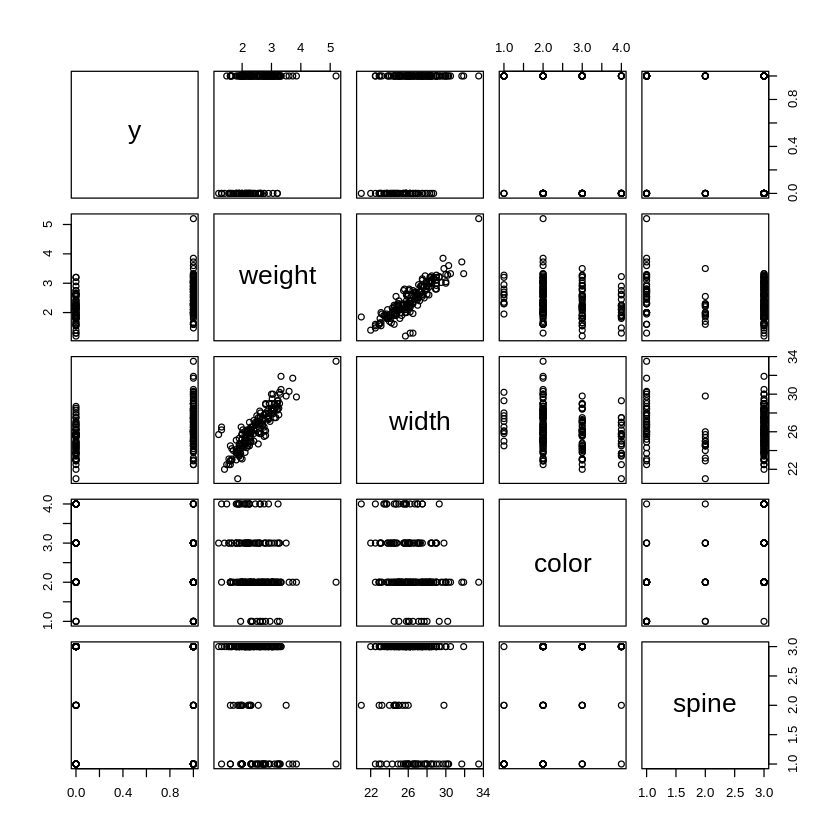

In [9]:
pairs(Data[,-c(1:2)])

In [10]:
t.test(weight~y, data=Data)


	Welch Two Sample t-test

data:  weight by y
t = -5.8879, df = 153.03, p-value = 2.39e-08
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -0.6204499 -0.3086936
sample estimates:
mean in group 0 mean in group 1 
       2.139113        2.603685 


- Categorical: Color and Spine

In [11]:
t.test(width~y, data=Data)


	Welch Two Sample t-test

data:  width by y
t = -6.0824, df = 149.24, p-value = 9.495e-09
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -2.332266 -1.188484
sample estimates:
mean in group 0 mean in group 1 
       25.16935        26.92973 


In [12]:
cor.test(Data$weight, Data$width)


	Pearson's product-moment correlation

data:  Data$weight and Data$width
t = 25.102, df = 171, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8501665 0.9149979
sample estimates:
      cor 
0.8868715 


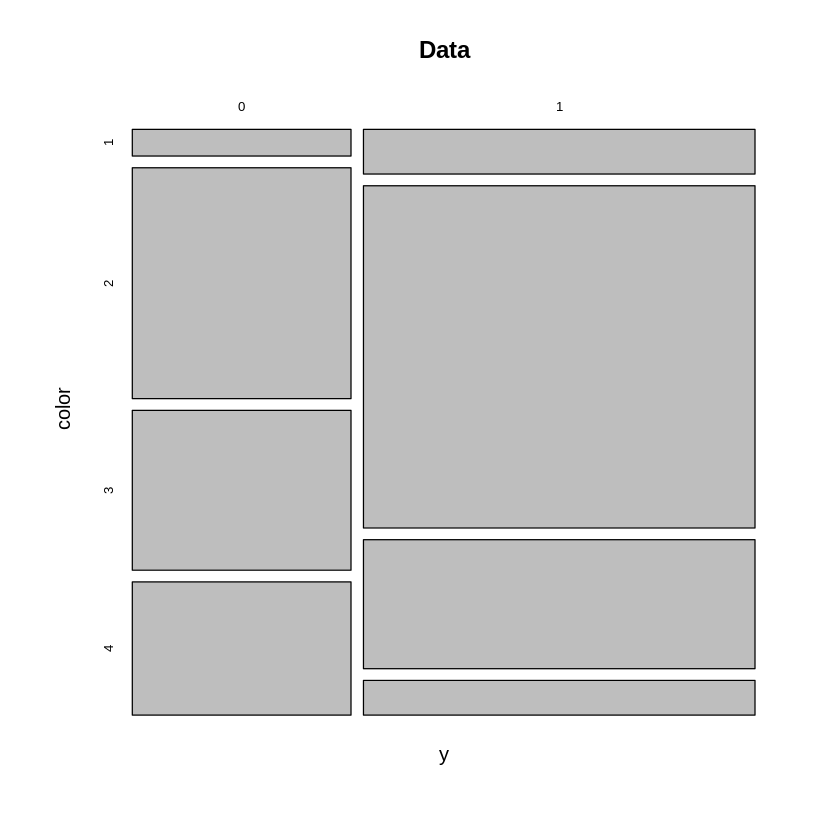

In [13]:
mosaicplot(y~color, data=Data)

In [14]:
chisq.test(table(Data$y, Data$color))

Warning message in chisq.test(table(Data$y, Data$color)):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  table(Data$y, Data$color)
X-squared = 14.078, df = 3, p-value = 0.002802


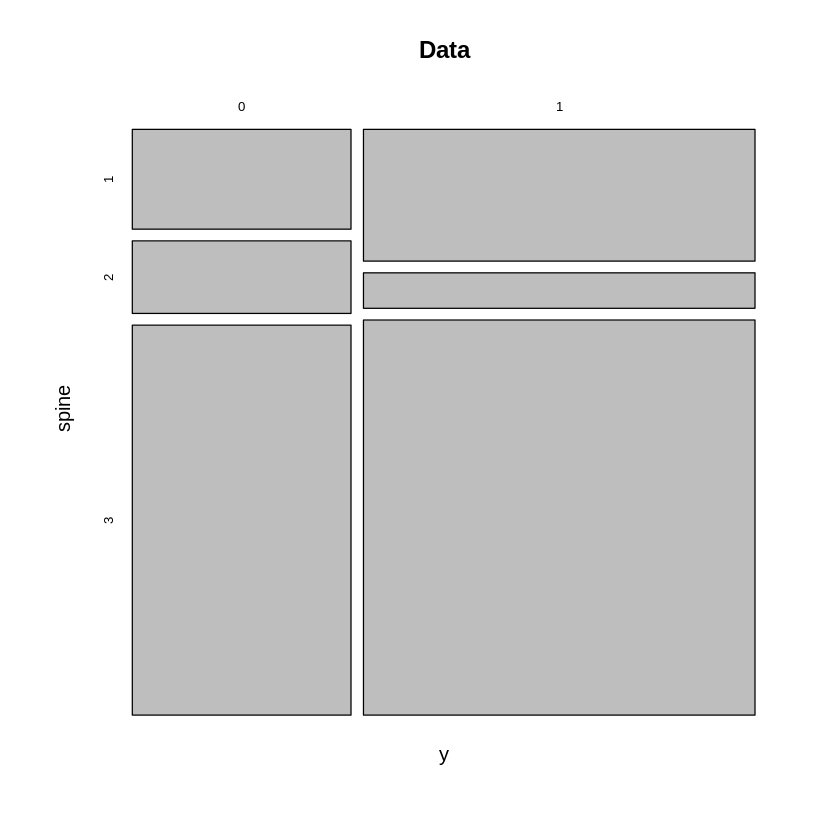

In [15]:
mosaicplot(y~spine, data=Data)

In [16]:
chisq.test(table(Data$y, Data$spine))


	Pearson's Chi-squared test

data:  table(Data$y, Data$spine)
X-squared = 2.6018, df = 2, p-value = 0.2723


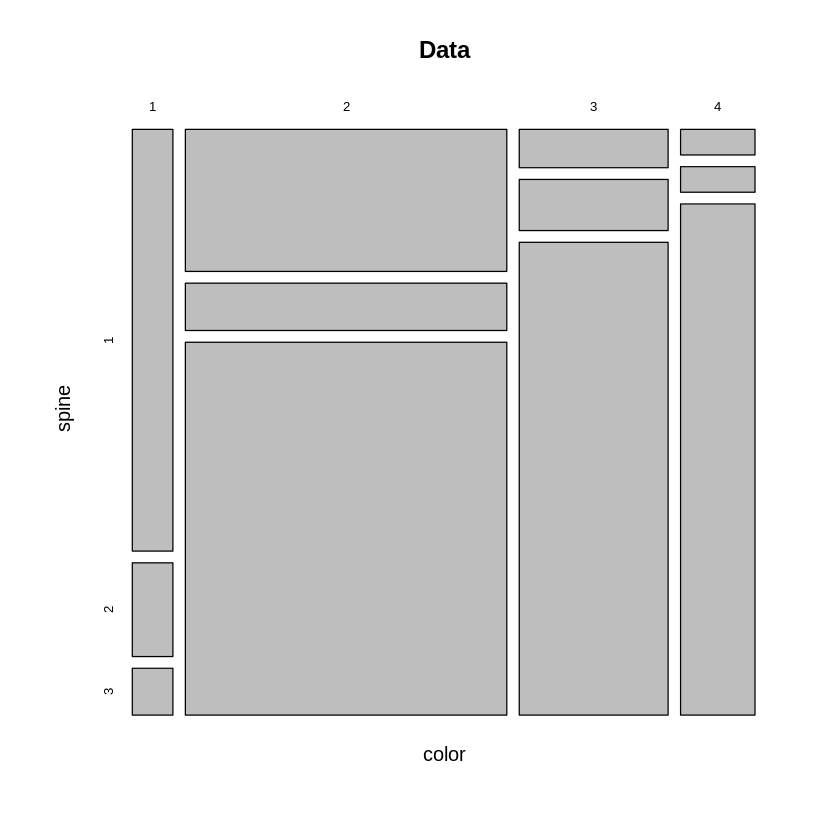

In [17]:
mosaicplot(color~spine, data=Data)

In [18]:
chisq.test(table(Data$color, Data$spine))

Warning message in chisq.test(table(Data$color, Data$spine)):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  table(Data$color, Data$spine)
X-squared = 34.745, df = 6, p-value = 4.83e-06


In [28]:
## chis-square test
### Observed Count
OC <- table(Data$color, Data$spine)
### Expected Count
EC <- apply(OC, 1, sum)%*%t(apply(OC, 2, sum))/sum(OC)
print(cbind(OC, round(EC, digits=2)))

   1 2  3     1    2     3
1  9 2  1  2.57 1.04  8.39
2 24 8 63 20.32 8.24 66.45
3  3 4 37  9.41 3.82 30.77
4  1 1 20  4.71 1.91 15.39


### 從圖中我看到：
  
  + "spine" 可能比較沒用。
  + "spine" 與 "color" 之間不獨立。
  + "weight" 與 "width" 高度相關，會造成多重共線性問題。
  
Note: when you have several variables, use all of these variables; when you have a lot of variables, screen out some uncorrelated (with the response variable) and highly correlated (among predictors) predictors prior to do further data analysis.

### 資料分析

  + 探索性實驗的目的就是要建立一個合理的預測模型
  + Begin with the most complex model and then do model selection.

In [20]:
## Full Model
log.fit <- glm(y~weight+width+factor(color)+factor(spine), family=binomial, data=Data)
summary(log.fit)


Call:
glm(formula = y ~ weight + width + factor(color) + factor(spine), 
    family = binomial, data = Data)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)  
(Intercept)    -8.06501    3.92855  -2.053   0.0401 *
weight          0.82578    0.70383   1.173   0.2407  
width           0.26313    0.19530   1.347   0.1779  
factor(color)2 -0.10290    0.78259  -0.131   0.8954  
factor(color)3 -0.48886    0.85312  -0.573   0.5666  
factor(color)4 -1.60867    0.93553  -1.720   0.0855 .
factor(spine)2 -0.09598    0.70337  -0.136   0.8915  
factor(spine)3  0.40029    0.50270   0.796   0.4259  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 225.76  on 172  degrees of freedom
Residual deviance: 185.20  on 165  degrees of freedom
AIC: 201.2

Number of Fisher Scoring iterations: 4


  + Model Selection by Backward and AIC

In [21]:
step(log.fit)

Start:  AIC=201.2
y ~ weight + width + factor(color) + factor(spine)

                Df Deviance    AIC
- factor(spine)  2   186.21 198.21
- weight         1   186.61 200.61
- width          1   187.00 201.00
<none>               185.20 201.20
- factor(color)  3   192.80 202.80

Step:  AIC=198.21
y ~ weight + width + factor(color)

                Df Deviance    AIC
- weight         1   187.46 197.46
<none>               186.21 198.21
- width          1   188.54 198.54
- factor(color)  3   192.89 198.89

Step:  AIC=197.46
y ~ width + factor(color)

                Df Deviance    AIC
<none>               187.46 197.46
- factor(color)  3   194.45 198.45
- width          1   212.06 220.06



Call:  glm(formula = y ~ width + factor(color), family = binomial, data = Data)

Coefficients:
   (Intercept)           width  factor(color)2  factor(color)3  factor(color)4  
     -11.38519         0.46796         0.07242        -0.22380        -1.32992  

Degrees of Freedom: 172 Total (i.e. Null);  168 Residual
Null Deviance:	    225.8 
Residual Deviance: 187.5 	AIC: 197.5

## Parsimonious Model

In [22]:
log.fit.1 <- glm(y~width+factor(color), family=binomial, data=Data)
summary(log.fit.1)


Call:
glm(formula = y ~ width + factor(color), family = binomial, data = Data)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -11.38519    2.87346  -3.962 7.43e-05 ***
width            0.46796    0.10554   4.434 9.26e-06 ***
factor(color)2   0.07242    0.73989   0.098    0.922    
factor(color)3  -0.22380    0.77708  -0.288    0.773    
factor(color)4  -1.32992    0.85252  -1.560    0.119    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 225.76  on 172  degrees of freedom
Residual deviance: 187.46  on 168  degrees of freedom
AIC: 197.46

Number of Fisher Scoring iterations: 4


### 考慮

1. 整併類別變數（why?）

In [23]:
Data$color2 <- as.factor(ifelse(Data$color == 1, 1, 0))
red.log.fit.2 <- glm(y~width+color2, family=binomial, data=Data)
summary(red.log.fit.2)


Call:
glm(formula = y ~ width + color2, family = binomial, data = Data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -12.2886     2.6343  -4.665 3.09e-06 ***
width         0.4943     0.1021   4.842 1.29e-06 ***
color21       0.2079     0.7236   0.287    0.774    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 225.76  on 172  degrees of freedom
Residual deviance: 194.37  on 170  degrees of freedom
AIC: 200.37

Number of Fisher Scoring iterations: 4


- The AIC for the 2-class color model is 200.37
- The AIC for the 4-class color model is 197.46
- Choose the 4-class color model

2. 考慮交互作用

In [24]:
log.fit.3 <- glm(y~width*factor(color), family=binomial, data=Data)
summary(log.fit.3)


Call:
glm(formula = y ~ width * factor(color), family = binomial, data = Data)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)
(Intercept)           -1.75261   11.46409  -0.153    0.878
width                  0.10600    0.42656   0.248    0.804
factor(color)2        -8.28735   12.00363  -0.690    0.490
factor(color)3       -19.76545   13.34251  -1.481    0.139
factor(color)4        -4.10122   13.27532  -0.309    0.757
width:factor(color)2   0.31287    0.44794   0.698    0.485
width:factor(color)3   0.75237    0.50435   1.492    0.136
width:factor(color)4   0.09443    0.50042   0.189    0.850

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 225.76  on 172  degrees of freedom
Residual deviance: 183.08  on 165  degrees of freedom
AIC: 199.08

Number of Fisher Scoring iterations: 5


- The AIC for the **without** interaction model is 197.46
- The AIC for the **with** interaction model is 199.08
- Choose the **without** interaction model

3. 是否該讓 color 變成連續變數

In [25]:
Data$color_c <- as.numeric(Data$color)
log.fit.c <- glm(y~width+color_c, family=binomial, data=Data)
summary(log.fit.c)


Call:
glm(formula = y ~ width + color_c, family = binomial, data = Data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -10.0708     2.8068  -3.588 0.000333 ***
width         0.4583     0.1040   4.406 1.05e-05 ***
color_c      -0.5090     0.2237  -2.276 0.022860 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 225.76  on 172  degrees of freedom
Residual deviance: 189.12  on 170  degrees of freedom
AIC: 195.12

Number of Fisher Scoring iterations: 4


- The AIC for the **discrete color** model is 197.46
- The AIC for the **continuous color** model is 195.12
- Choose the **continuous color** model

### 最後看一下預測能力

- Categorical Color

Area under the curve: 0.7713

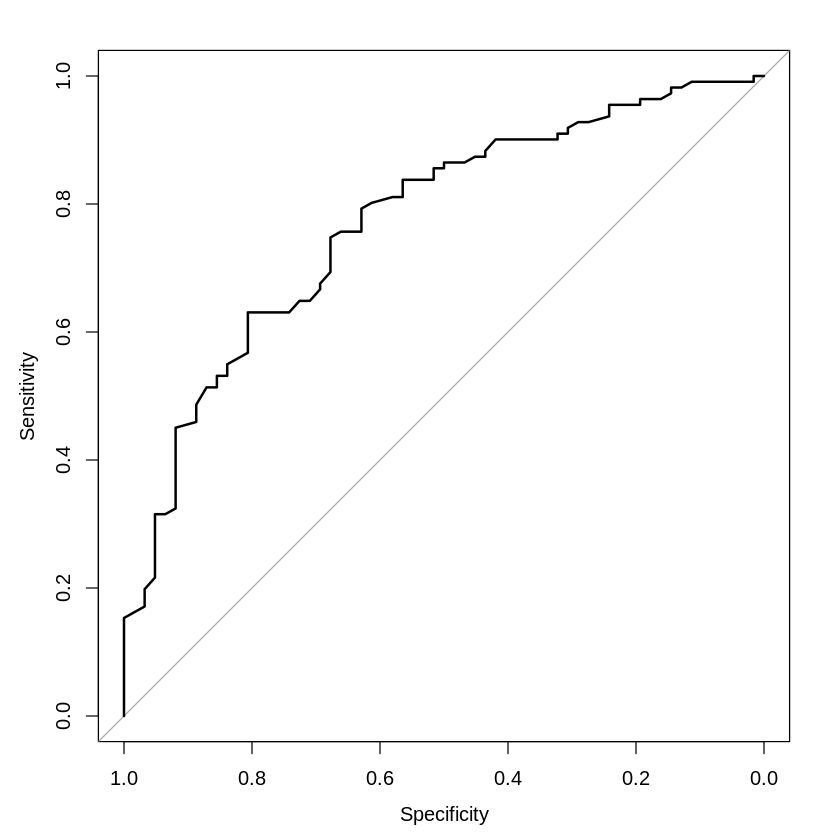

In [ ]:
library(pROC)
pred_cate <- predict(log.fit.1, type="response")
roc_cate <- roc(Data$y, pred_cate, quiet=TRUE)
auc(roc_cate); plot(roc_cate)

- Continuous Color

Area under the curve: 0.7622

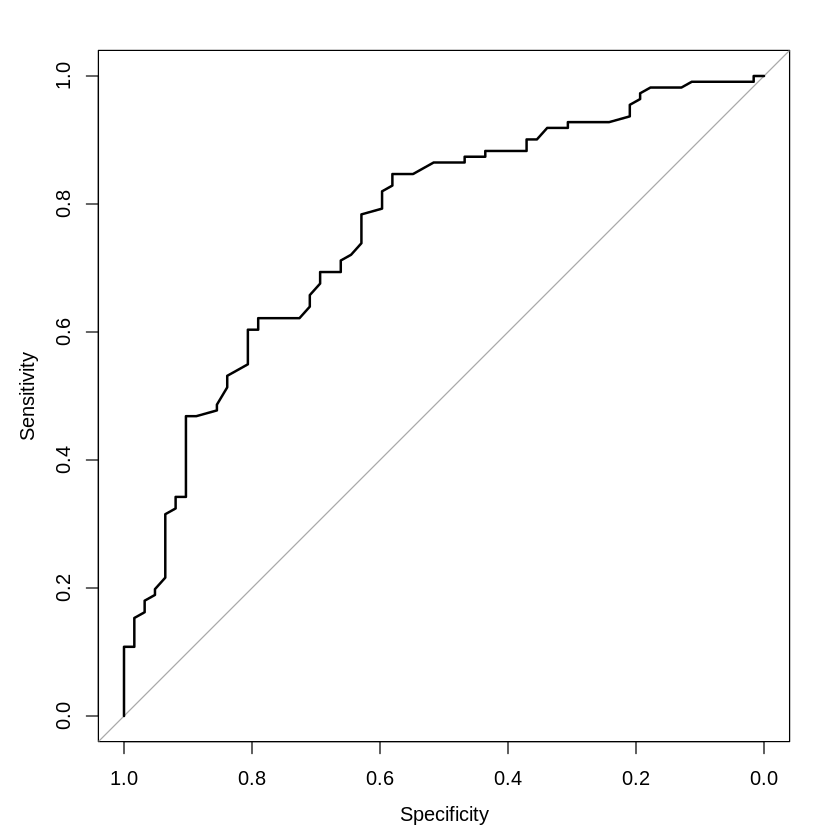

In [31]:
pred_cont <- predict(log.fit.c, type="response")
roc_cont <- roc(Data$y, pred_cont, quiet=TRUE)
auc(roc_cont); plot(roc_cont)

### 總結： 

- *連續模型* 與 *類別模型* 差不多。我選 *類別模型* 因為比較有故事性，而且用掉的自由度也沒有差太多。

- 模型
  $$
    \log \frac{\pi}{1-\pi} = -11.385 + 0.468 \text{ width} + 0.072 c_2 - 0.223 c_3 - 1.330 c_4
  $$
- Odds ratio

In [32]:
print(coefficients(log.fit.1))

   (Intercept)          width factor(color)2 factor(color)3 factor(color)4 
  -11.38519276     0.46795598     0.07241694    -0.22379766    -1.32991913 


In [33]:
print(exp(coefficients(log.fit.1)))

   (Intercept)          width factor(color)2 factor(color)3 factor(color)4 
  1.136249e-05   1.596727e+00   1.075104e+00   7.994769e-01   2.644987e-01 


In [34]:
print(round(exp(confint(log.fit.1)), digits=3))

Waiting for profiling to be done...



               2.5 % 97.5 %
(Intercept)    0.000  0.003
width          1.312  1.988
factor(color)2 0.214  4.270
factor(color)3 0.151  3.454
factor(color)4 0.043  1.315


- 在顏色不變的條件之下，母鱟甲殻每增加一單位，該鱟身邊有公鱟相隨的成敗比是原來的1.597倍。Odds ratio 的95%信賴區間為(1.312, 1.988).
- 有關顏色的 odds ratio 的解釋

  - 比起顏色1，母鱟為顏色2時，該鱟身邊有公鱟相隨的成敗比是原來的1.075倍。
  - 比起顏色1，母鱟為顏色3時，該鱟身邊有公鱟相隨的成敗比是原來的0.799倍。
  - 比起顏色1，母鱟為顏色4時，該鱟身邊有公鱟相隨的成敗比是原來的0.266倍。

- 比起顏色2，母鱟為顏色4時，該鱟身邊有公鱟相隨的成敗比是原來的多少倍？

In [35]:
beta <- coefficients(log.fit.1)
V.beta <- vcov(log.fit.1)
contrast <- c(0, 0, -1, 0, 1)

diff <- sum(beta*contrast)
diff.se <- sqrt(t(contrast)%*%V.beta%*%contrast)
lb <- round(exp(diff - 1.96*diff.se), digits=3)
ub <- round(exp(diff + 1.96*diff.se), digits=3)
cat("Odds ratio=", round(exp(diff), digits=3), "with 95% CI=[", lb, ",", ub, "]\n")

Odds ratio= 0.246 with 95% CI=[ 0.084 , 0.721 ]


### Homework 3 Due 2026/04/23

#### 糖尿病預測分析

In [36]:
diabete <-read.csv("https://gist.githubusercontent.com/chaityacshah/899a95deaf8b1930003ae93944fd17d7/raw/3d35de839da708595a444187e9f13237b51a2cbe/pima-indians-diabetes.csv")
colnames(diabete) <- c("pregnant","glucose", "blood_pressure", "triceps", "serum_insulin", "mass", "pedigree" , "age","diabetes")
str(diabete)

'data.frame':	768 obs. of  9 variables:
 $ pregnant      : int  6 1 8 1 0 5 3 10 2 8 ...
 $ glucose       : int  148 85 183 89 137 116 78 115 197 125 ...
 $ blood_pressure: int  72 66 64 66 40 74 50 0 70 96 ...
 $ triceps       : int  35 29 0 23 35 0 32 0 45 0 ...
 $ serum_insulin : int  0 0 0 94 168 0 88 0 543 0 ...
 $ mass          : num  33.6 26.6 23.3 28.1 43.1 25.6 31 35.3 30.5 0 ...
 $ pedigree      : num  0.627 0.351 0.672 0.167 2.288 ...
 $ age           : int  50 31 32 21 33 30 26 29 53 54 ...
 $ diabetes      : int  1 0 1 0 1 0 1 0 1 1 ...


- Response
  - diabetes: 糖尿病（1:有、0:無）
- Covariates
  - pregnant: 懷孕次數
  - glucose: 血漿葡萄糖濃度
  - blood_pressure: 舒張壓
  - triceps: 三頭肌皮膚褶皺厚度
  - serum_insulin: 血清胰島素
  - mass: BMI
  - pedigree: 糖尿病譜系功能
  - age: 年齡

- Data Analysis
  - Visualization
  - Do model selection for main effect
  - Categorize blood_pressure / serum_insulin variables
  - Does categorized variables fit data better?
  - Consider interaction effect
  - Give me your final model and explain the model